# Lab 1 — Introduction to Python for Linear Algebra

**Python version of the MATLAB lab**


## Main goals

By the end of this lab, you should be able to:

1. Use Python as a calculator.
2. Create vectors and matrices.
3. Understand row vectors, column vectors, matrix shapes, and broadcasting.
4. Perform matrix operations and component-wise operations.
5. Construct structured vectors and matrices.
6. Visualize functions, points, grids, and geometric structures.
7. Use loops for repeated computation and plotting.
8. Solve linear systems using numerical and symbolic tools.
9. Interpret systems with unique solutions, infinitely many solutions, or no exact solution.
10. Model simple truss-force problems as linear systems.

## 0. Setup

We will use the following Python packages.

- `numpy`: numerical arrays, vectors, matrices, and linear algebra.
- `matplotlib`: plotting.
- `sympy`: exact symbolic mathematics and reduced row echelon form.
- `scipy.linalg`: null spaces and additional numerical linear algebra.

Run the next cell first.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from scipy.linalg import null_space

# Make numpy printouts easier to read.
np.set_printoptions(precision=4, suppress=True)

print("Setup complete.")

Setup complete.


## 0.1 MATLAB-to-Python Translation Guide

The original lab uses MATLAB notation. In Python, the closest standard tools are `numpy` and `sympy`.

| Task | MATLAB | Python / NumPy |
|---|---|---|
| Row vector | `[1 2 3]` | `np.array([1, 2, 3])` |
| Column vector | `[1;2;3]` | `np.array([[1], [2], [3]])` |
| Matrix | `[1 2; 3 4]` | `np.array([[1, 2], [3, 4]])` |
| Transpose | `A'` | `A.T` |
| Matrix multiplication | `A*B` | `A @ B` |
| Component-wise multiplication | `A.*B` | `A * B` |
| Component-wise square | `X.^2` | `X**2` |
| Solve linear system | `A\b` | `np.linalg.solve(A, b)` if square; `np.linalg.lstsq(A, b)` more generally |
| RREF | `rref(A)` | `sp.Matrix(A).rref()` |
| Inverse | `inv(A)` | `np.linalg.inv(A)` |
| Zeros | `zeros(n,m)` | `np.zeros((n,m))` |
| Ones | `ones(n,m)` | `np.ones((n,m))` |
| Random matrix | `rand(n,m)` | `np.random.rand(n,m)` |
| Sequence | `3:10` | `np.arange(3, 11)` |
| Step sequence | `3:4:20` | `np.arange(3, 21, 4)` |
| Smooth grid | `1:.01:10` | `np.arange(1, 10.01, 0.01)` or `np.linspace(...)` |

# 1. Linear Algebra in Python

Python was not originally built only for matrices, but with `numpy` it becomes a powerful environment for scientific computing and linear algebra. In this lab, a vector is a one-dimensional or two-dimensional `numpy` array, and a matrix is a two-dimensional `numpy` array.

Compared with MATLAB, Python is more explicit about shapes. This is useful because many linear algebra mistakes are really shape mistakes.

## 1.1 Python as a Calculator

At its simplest, Python can be used as a calculator.

In [ ]:
1 + 1

2

To store the result of a computation, assign it to a variable.

In [ ]:
myvar = 5 + 7 + 9
myvar

21

We may then use this variable in later computations.

In [ ]:
myvar * 8

168

In [ ]:
myvar = 400 / 20
myvar

20.0

In [ ]:
myvar = myvar / 100
myvar

0.2

### Question 1.1

What are the results of each of the computations above? If you perform them in a different order, do you get the same result?

### Solution

The computations are:

1. `5 + 7 + 9 = 21`
2. `myvar * 8 = 168` if `myvar` is still `21`
3. `400 / 20 = 20`
4. `myvar / 100 = 0.2` if `myvar` has just been reset to `20`

The order matters because `myvar` changes whenever we reassign it.

## 1.1.1 Operators and Order of Operations

Common Python operators:

| Symbol | Meaning |
|---|---|
| `+` | Addition |
| `-` | Negation or subtraction |
| `*` | Multiplication |
| `/` | Division |
| `**` | Exponentiation |

The usual order of operations applies:

1. Parentheses
2. Exponentiation
3. Negation
4. Multiplication and division
5. Addition and subtraction

In Python, exponentiation is written with `**`, not `^`.

In [ ]:
-10**(-4) / 2 + (10 + 2**1 * 2)

13.99995

### Important note about negative powers

In Python, `-10**(-4)` is interpreted as `-(10**(-4))`, not `(-10)**(-4)`. Parentheses remove ambiguity.

In [ ]:
-(10**(-4)), (-10)**(-4)

(-0.0001, 0.0001)

# 1.2 Vectors

In Python with `numpy`, vectors are usually represented by arrays.

A one-dimensional vector:

In [ ]:
vec1 = np.array([1, 2, 3, 4])
vec2 = np.array([7, 10, 30, 50])

print("vec1 =", vec1)
print("vec2 =", vec2)
print("shape of vec1:", vec1.shape)

vec1 = [1 2 3 4]
vec2 = [ 7 10 30 50]
shape of vec1: (4,)


A column vector should be written as a two-dimensional array with shape `(n, 1)`.

In [ ]:
vec3 = np.array([[-1], [-4], [-9], [-16]])

print("vec3 =")
print(vec3)
print("shape of vec3:", vec3.shape)

vec3 =
[[ -1]
 [ -4]
 [ -9]
 [-16]]
shape of vec3: (4, 1)


Transpose changes a column vector into a row vector.

In [ ]:
print("vec3.T =")
print(vec3.T)
print("shape of vec3.T:", vec3.T.shape)

vec3.T =
[[ -1  -4  -9 -16]]
shape of vec3.T: (1, 4)


### Indexing

MATLAB starts indexing at `1`, but Python starts indexing at `0`.

So:

- MATLAB `vec2(1)` corresponds to Python `vec2[0]`.
- MATLAB `vec3(4)` corresponds to Python `vec3[3, 0]`.

In [ ]:
print("First entry of vec2:", vec2[0])
print("Fourth entry of vec3:", vec3[3, 0])

First entry of vec2: 7
Fourth entry of vec3: -16


## 1.2.1 Vector Operations

Vectors of compatible shape can be added.

In [ ]:
vec1 + vec2

array([ 8, 12, 33, 54])

A vector can be multiplied by a scalar.

In [ ]:
4 * vec1

array([ 4,  8, 12, 16])

A scalar can be added to every component of a vector.

In [ ]:
vec2 + 4

array([11, 14, 34, 54])

## 1.2.2 Broadcasting

In MATLAB, adding a row vector and a column vector can produce a matrix. NumPy has a similar idea called **broadcasting**.

Here `vec1` has shape `(4,)` and `vec3` has shape `(4,1)`. NumPy broadcasts them to produce a `4 x 4` matrix.

In [ ]:
vec1 + vec3

array([[  0,   1,   2,   3],
       [ -3,  -2,  -1,   0],
       [ -8,  -7,  -6,  -5],
       [-15, -14, -13, -12]])

This matrix has entries

$$
(\text{vec1} + \text{vec3})_{ij} = \text{vec1}_j + \text{vec3}_i.
$$

Broadcasting is useful, but it can also hide mistakes. Always check shapes.

## 1.2.3 Vector Multiplication

In NumPy:

- `vec1 * vec2` means component-wise multiplication.
- `vec1 @ vec2` means dot product if both are one-dimensional arrays.
- Matrix multiplication involving column vectors should use two-dimensional arrays.

In [ ]:
print("Component-wise multiplication:", vec1 * vec2)
print("Dot product:", vec1 @ vec2)

Component-wise multiplication: [  7  20  90 200]
Dot product: 317


Trying incompatible matrix multiplication gives an error.

In [ ]:
try:
    vec1 @ vec3
except Exception as e:
    print(type(e).__name__ + ":", e)

The expression `vec1 @ vec3` is actually valid because `vec1` is treated like a row vector of length 4 and `vec3` is a column vector of shape `(4,1)`, so the result is a shape `(1,)` array.

In [ ]:
vec1 @ vec3

array([-100])

For an outer product, use a column vector times a row vector.

In [ ]:
outer_product = vec3 @ vec1.reshape(1, 4)
outer_product

array([[ -1,  -2,  -3,  -4],
       [ -4,  -8, -12, -16],
       [ -9, -18, -27, -36],
       [-16, -32, -48, -64]])

### Question 1.2

With `vec1`, `vec2`, and `vec3` defined above, which of the following are valid?

1. `vec1 * vec2`
2. `vec1 @ vec2`
3. `vec1 * vec3`
4. `vec1 @ vec3`
5. `vec3 @ vec1`

### Solution

- `vec1 * vec2` is valid component-wise multiplication.
- `vec1 @ vec2` is valid dot product.
- `vec1 * vec3` is valid by broadcasting and returns a `4 x 4` matrix.
- `vec1 @ vec3` is valid and returns a one-entry array.
- `vec3 @ vec1` is not valid because `vec3` has shape `(4,1)` and `vec1` has shape `(4,)`. The inner dimensions do not match.

In [ ]:
expressions = {
    "vec1 * vec2": lambda: vec1 * vec2,
    "vec1 @ vec2": lambda: vec1 @ vec2,
    "vec1 * vec3": lambda: vec1 * vec3,
    "vec1 @ vec3": lambda: vec1 @ vec3,
    "vec3 @ vec1": lambda: vec3 @ vec1,
}

for name, expr in expressions.items():
    print("\n", name)
    try:
        print(expr())
    except Exception as e:
        print(type(e).__name__ + ":", e)


 vec1 * vec2
[  7  20  90 200]

 vec1 @ vec2
317

 vec1 * vec3
[[ -1  -2  -3  -4]
 [ -4  -8 -12 -16]
 [ -9 -18 -27 -36]
 [-16 -32 -48 -64]]

 vec1 @ vec3
[-100]

 vec3 @ vec1
ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 1)


# 1.3 Matrices

A matrix is a two-dimensional array. For example,

$$
\begin{pmatrix}
1 & 3 & 5 \\
7 & 9 & 11
\end{pmatrix}
$$

can be constructed as follows.

In [ ]:
mat1 = np.array([[1, 3, 5],
                 [7, 9, 11]])

mat2 = np.array([[2, 4, 6],
                 [8, 10, 12]])

print("mat1 =")
print(mat1)
print("\nmat2 =")
print(mat2)

mat1 =
[[ 1  3  5]
 [ 7  9 11]]

mat2 =
[[ 2  4  6]
 [ 8 10 12]]


Access entries by row and column. Remember that Python indexing starts at `0`.

In [ ]:
print("mat2[0,0] =", mat2[0, 0])
print("mat2[1,2] =", mat2[1, 2])

mat2[0,0] = 2
mat2[1,2] = 12


The number of elements and the matrix dimensions are:

In [ ]:
print("Number of elements in mat1:", mat1.size)
print("Shape of mat1:", mat1.shape)

Number of elements in mat1: 6
Shape of mat1: (2, 3)


## 1.3.1 Matrix Operations

For a matrix `M`:

| Operation | Python |
|---|---|
| Matrix multiplication | `M @ N` |
| Component-wise multiplication | `M * N` |
| Transpose | `M.T` |
| Inverse | `np.linalg.inv(M)` |

The matrix product `mat1 @ mat2.T` is square.

In [ ]:
product = mat1 @ mat2.T
product

array([[ 44,  98],
       [116, 278]])

In [ ]:
A = np.linalg.inv(product)
A

array([[ 0.3218, -0.1134],
       [-0.1343,  0.0509]])

### Question 1.3

What is the result of multiplying `A` by `mat1`, where

$$
A = ( \text{mat1} \cdot \text{mat2}^T )^{-1}?
$$

### Solution

In [ ]:
A @ mat1

array([[-0.4722, -0.0556,  0.3611],
       [ 0.2222,  0.0556, -0.1111]])

This is a `2 x 3` matrix. It is not expected to be the identity matrix because `mat1` is not square. However,

$$
A(\text{mat1}\text{mat2}^T) = I_2.
$$

In [ ]:
A @ (mat1 @ mat2.T)

array([[ 1., -0.],
       [-0.,  1.]])

# 1.4 Constructing Vectors and Matrices

NumPy has several useful ways to construct vectors and matrices.

## 1.4.1 Sequences

In MATLAB, `3:10` gives integers from `3` to `10`.

In Python, use `np.arange(3, 11)` because the endpoint is excluded.

In [ ]:
vec1 = np.arange(3, 11)
vec1

array([ 3,  4,  5,  6,  7,  8,  9, 10])

A sequence with step size `4`:

In [ ]:
vec2 = np.arange(3, 21, 4)
vec2

array([ 3,  7, 11, 15, 19])

Counting down:

In [ ]:
vec4 = np.arange(20, 0, -2)
vec4

array([20, 18, 16, 14, 12, 10,  8,  6,  4,  2])

For smooth plotting, `np.linspace` is often better than `np.arange`.

In [ ]:
X = np.linspace(1, 10, 901)
print(X[:5])
print(X[-5:])

[1.   1.01 1.02 1.03 1.04]
[ 9.96  9.97  9.98  9.99 10.  ]


## 1.4.2 Matrix Construction Functions

Basic construction functions:

| Matrix | Python |
|---|---|
| $n \times m$ zeros | `np.zeros((n,m))` |
| $n \times m$ ones | `np.ones((n,m))` |
| $n \times m$ random matrix in $[0,1]$ | `np.random.rand(n,m)` |
| Identity matrix | `np.eye(n)` |

In [ ]:
print("Zeros:")
print(np.zeros((2, 5)))

print("\nOnes:")
print(np.ones((2, 5)))

print("\nRandom:")
print(np.random.rand(2, 5))

print("\nIdentity:")
print(np.eye(4))

Zeros:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Ones:
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

Random:
[[0.4078 0.3067 0.0695 0.8524 0.4721]
 [0.781  0.3855 0.7705 0.6754 0.8258]]

Identity:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


We can build a matrix by stacking rows.

In [ ]:
mat = np.vstack([
    np.arange(1, 6),
    np.arange(2, 11, 2),
    4 * np.ones(5)
])

mat

array([[ 1.,  2.,  3.,  4.,  5.],
       [ 2.,  4.,  6.,  8., 10.],
       [ 4.,  4.,  4.,  4.,  4.]])

### Question 1.4

Use matrix addition, multiplication, and matrix construction functions to build:

1. A $2 \times 5$ matrix with $-1$ in the first row and the odd numbers starting at $5$ in the second row.
2. A random matrix with all numbers between $20$ and $30$.
3. A $100 \times 100$ multiplication table matrix

$$
\begin{pmatrix}
1 & 2 & 3 & \cdots \\
2 & 4 & 6 & \cdots \\
3 & 6 & 9 & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{pmatrix}.
$$

### Solution

In [ ]:
# 1. 2 x 5 matrix
M1 = np.vstack([
    -np.ones(5),
    np.arange(5, 15, 2)
])
print("M1 =")
print(M1)

# 2. Random matrix between 20 and 30
M2 = 20 + 10 * np.random.rand(3, 4)
print("\nM2 =")
print(M2)

# 3. 100 x 100 multiplication table
v = np.arange(1, 101).reshape(100, 1)
M3 = v @ v.T

print("\nTop-left corner of M3:")
print(M3[:5, :5])
print("Shape of M3:", M3.shape)

M1 =
[[-1. -1. -1. -1. -1.]
 [ 5.  7.  9. 11. 13.]]

M2 =
[[20.7651 23.595  28.7579 23.6872]
 [26.378  24.5855 25.3258 27.2711]
 [25.0499 26.8118 21.2158 28.9616]]

Top-left corner of M3:
[[ 1  2  3  4  5]
 [ 2  4  6  8 10]
 [ 3  6  9 12 15]
 [ 4  8 12 16 20]
 [ 5 10 15 20 25]]
Shape of M3: (100, 100)


# 1.5 Visualization with Python

In Python, we use `matplotlib.pyplot` for plotting.

A plot of a function is created by giving the plotting command two arrays:

- `X`: the $x$-values
- `Y`: the $y$-values

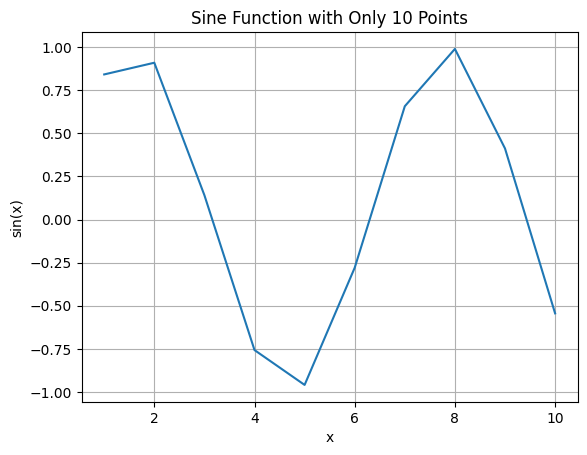

In [ ]:
X = np.arange(1, 11)
Y = np.sin(X)

plt.figure()
plt.plot(X, Y)
plt.title("Sine Function with Only 10 Points")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()

### Question 1.5

Looking at `X` and `Y`, we are only plotting 10 data points. Make the plot smoother by plotting all points from $1$ to $10$ up to two decimal places.

### Solution

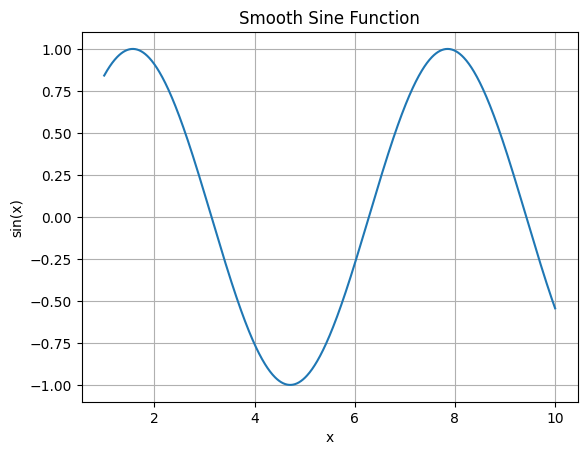

In [ ]:
X = np.arange(1, 10.01, 0.01)
Y = np.sin(X)

plt.figure()
plt.plot(X, Y)
plt.title("Smooth Sine Function")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()

## 1.5.1 Line Styles, Markers, and Colors

Matplotlib has many style options. A few common ones:

| MATLAB style idea | Matplotlib example |
|---|---|
| Red dashed line with x markers | `'r--x'` |
| Blue point markers | `'b.'` |
| Circle markers, no line | `'o'` with `linestyle='None'` |
| Thick line | `linewidth=3` |

Example:

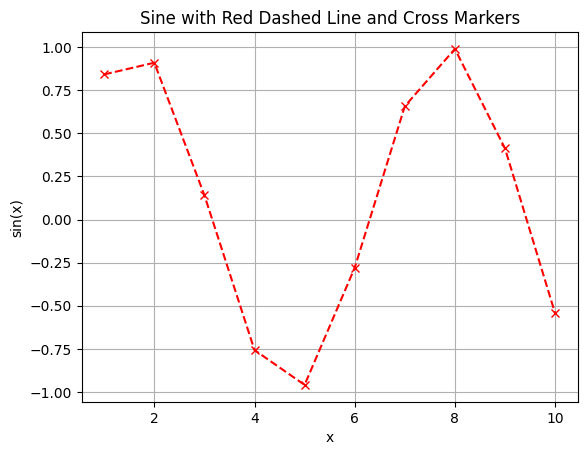

In [ ]:
X = np.arange(1, 11)
Y = np.sin(X)

plt.figure()
plt.plot(X, Y, "r--x")
plt.title("Sine with Red Dashed Line and Cross Markers")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()

If you want markers only and no connecting line:

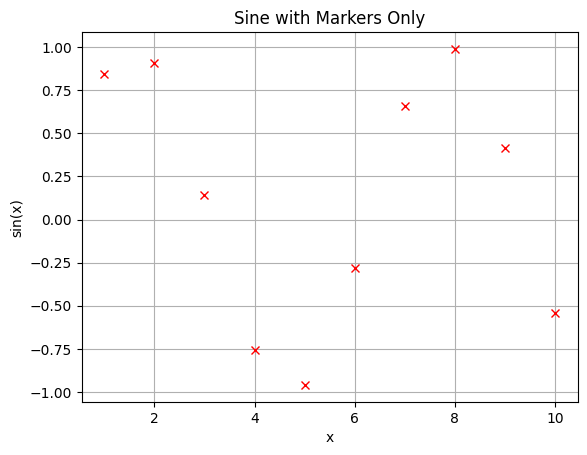

In [ ]:
plt.figure()
plt.plot(X, Y, "rx", linestyle="None")
plt.title("Sine with Markers Only")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()

### Question 1.6

Plot cosine from $-\pi$ to $\pi$ with blue point markers and no connecting lines.

### Solution

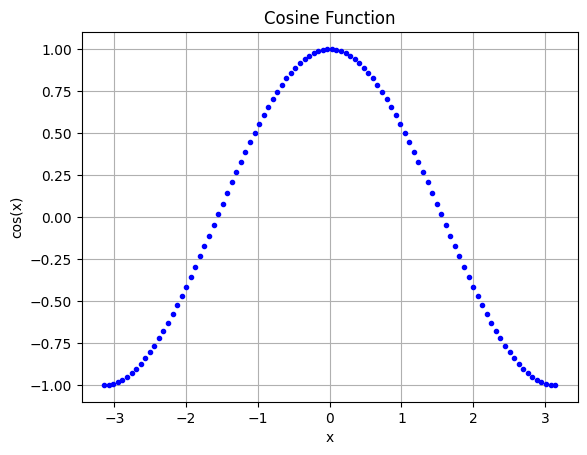

In [ ]:
X = np.linspace(-np.pi, np.pi, 100)
Y = np.cos(X)

plt.figure()
plt.plot(X, Y, "b.", linestyle="None")
plt.title("Cosine Function")
plt.xlabel("x")
plt.ylabel("cos(x)")
plt.grid(True)
plt.show()

## 1.5.2 Multiple Figures and Multiple Plots

Each `plt.figure()` creates a new figure.

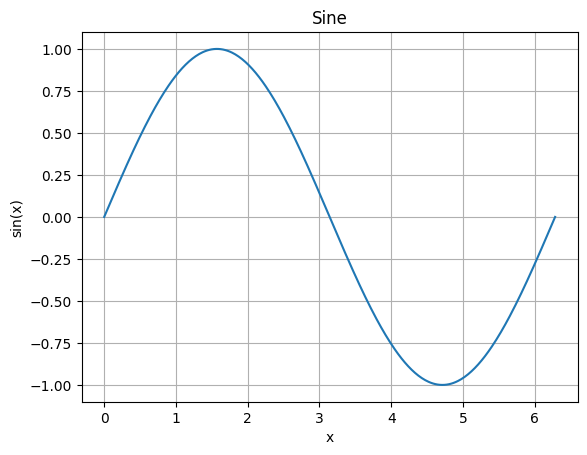

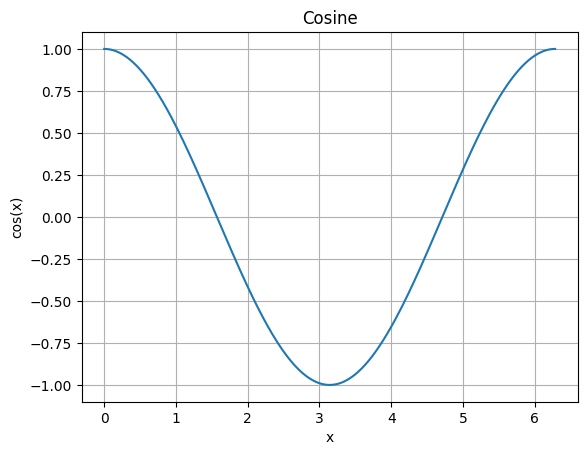

In [ ]:
X = np.linspace(0, 2*np.pi, 400)

plt.figure()
plt.plot(X, np.sin(X))
plt.title("Sine")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(X, np.cos(X))
plt.title("Cosine")
plt.xlabel("x")
plt.ylabel("cos(x)")
plt.grid(True)
plt.show()

To plot multiple functions on the same axes, call `plt.plot` more than once before `plt.show()`.

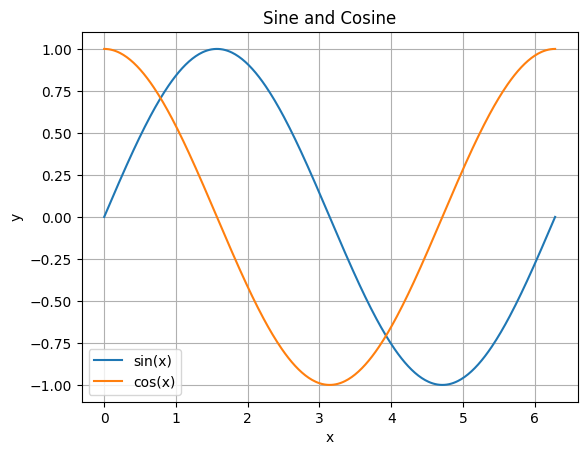

In [ ]:
plt.figure()
plt.plot(X, np.sin(X), label="sin(x)")
plt.plot(X, np.cos(X), label="cos(x)")
plt.title("Sine and Cosine")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

### Question 1.7

Plot the functions

$$
\frac{x}{x^2+1}
\qquad \text{and} \qquad
\cos(1/x)
$$

from $1$ to $4$ on the same plot.

### Solution

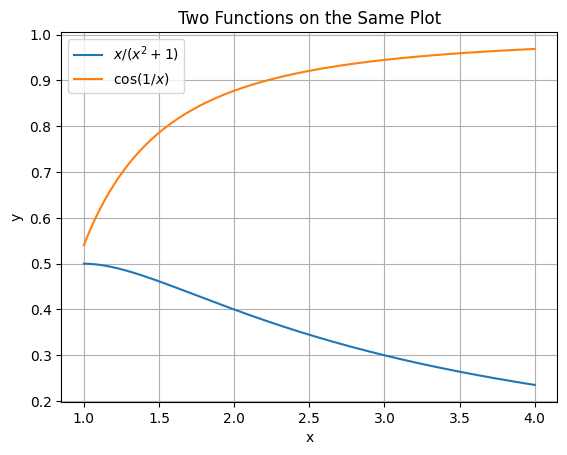

In [ ]:
X = np.linspace(1, 4, 500)

Y1 = X / (X**2 + 1)
Y2 = np.cos(1 / X)

plt.figure()
plt.plot(X, Y1, label=r"$x/(x^2+1)$")
plt.plot(X, Y2, label=r"$\cos(1/x)$")
plt.title("Two Functions on the Same Plot")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 1.5.3 2D Plotting with Points

We can draw geometric figures by specifying $x$-coordinates and $y$-coordinates.

For example, draw the diamond with points

$$
(1,0),\quad (0,1),\quad (-1,0),\quad (0,-1).
$$

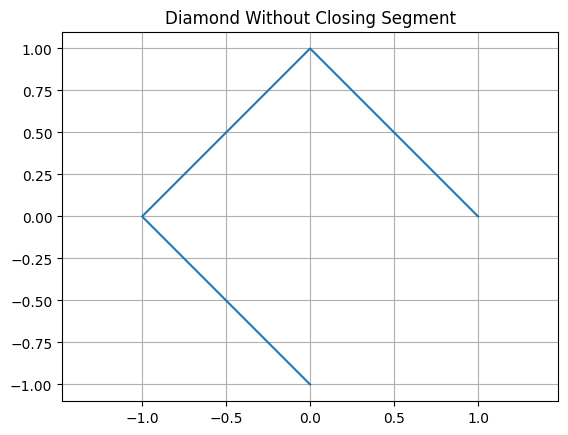

In [ ]:
X = np.array([1, 0, -1, 0])
Y = np.array([0, 1, 0, -1])

plt.figure()
plt.plot(X, Y)
plt.title("Diamond Without Closing Segment")
plt.axis("equal")
plt.grid(True)
plt.show()

The figure is not closed because we did not return to the starting point. Add $(1,0)$ again at the end.

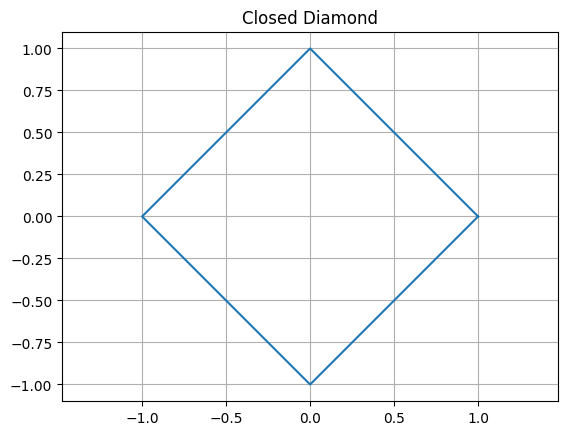

In [ ]:
X = np.array([1, 0, -1, 0, 1])
Y = np.array([0, 1, 0, -1, 0])

plt.figure()
plt.plot(X, Y)
plt.title("Closed Diamond")
plt.axis("equal")
plt.grid(True)
plt.show()

### Question 1.8

Plot a $3 \times 3$ grid with no connecting lines and circle markers. Can you find a clever way to define the vectors `X` and `Y`?

### Solution

Use `np.meshgrid`.

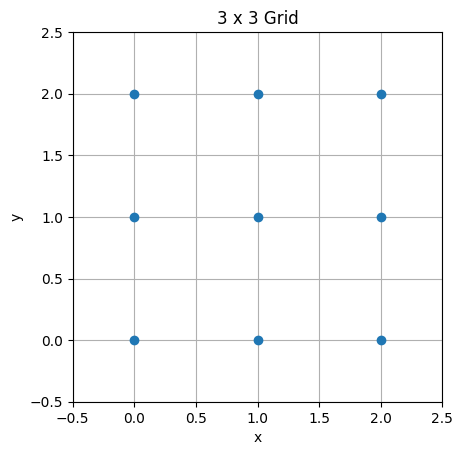

In [ ]:
x_values = np.arange(3)
y_values = np.arange(3)

XX, YY = np.meshgrid(x_values, y_values)

X = XX.ravel()
Y = YY.ravel()

plt.figure()
plt.plot(X, Y, "o", linestyle="None")
plt.title("3 x 3 Grid")
plt.xlabel("x")
plt.ylabel("y")
plt.axis([-0.5, 2.5, -0.5, 2.5])
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.show()

## 1.5.4 Axis Boundaries and Labels

Use:

```python
plt.axis([x_min, x_max, y_min, y_max])
```

to control the visible range.

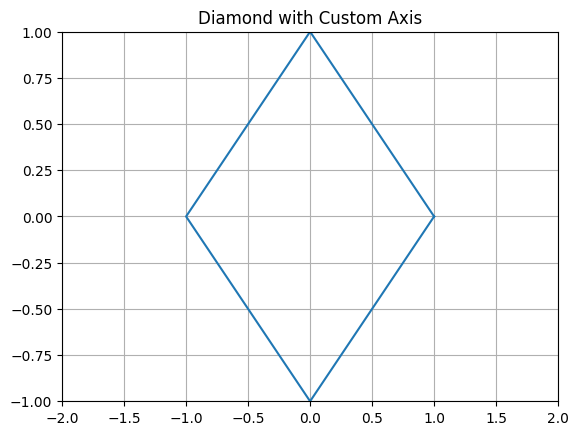

In [ ]:
X = np.array([1, 0, -1, 0, 1])
Y = np.array([0, 1, 0, -1, 0])

plt.figure()
plt.plot(X, Y)
plt.axis([-2, 2, -1, 1])
plt.title("Diamond with Custom Axis")
plt.grid(True)
plt.show()

Use `plt.text(x, y, label)` to label points.

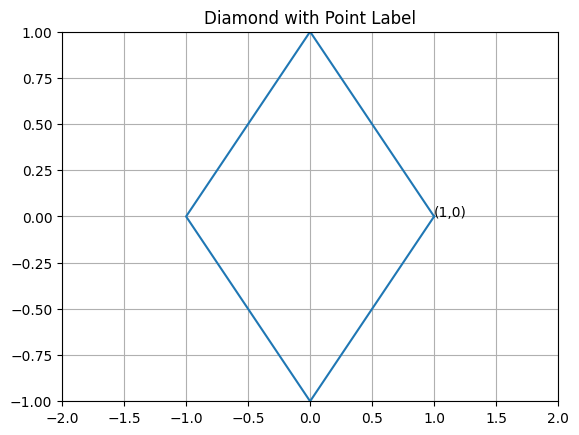

In [ ]:
X = np.array([1, 0, -1, 0, 1])
Y = np.array([0, 1, 0, -1, 0])

plt.figure()
plt.plot(X, Y)
plt.axis([-2, 2, -1, 1])
plt.title("Diamond with Point Label")
plt.grid(True)

plt.text(1, 0, "(1,0)")

plt.show()

# 1.6 Some Basic Looping

A `for` loop performs an action for each element in a list or array.

Example: square the numbers from $1$ to $10$.

In [ ]:
for i in range(1, 11):
    print(i, i**2)

1 1
2 4
3 9
4 16
5 25
6 36
7 49
8 64
9 81
10 100


Example: plot $\sin(x+n)$ for $n = 0,1,\ldots,20$ on the same plot.

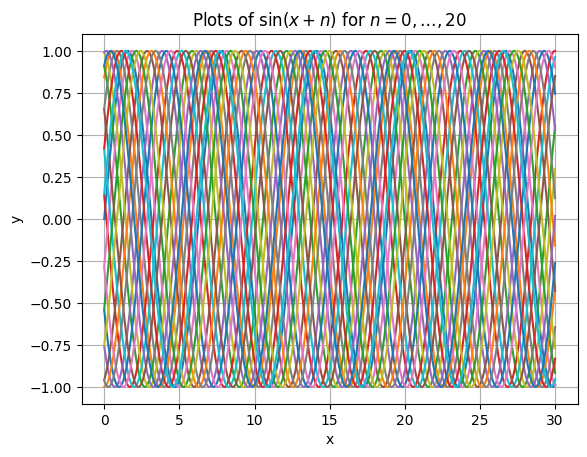

In [ ]:
X = np.arange(0, 30.01, 0.01)

plt.figure()
for n in range(21):
    plt.plot(X, np.sin(X + n))

plt.title(r"Plots of $\sin(x+n)$ for $n=0,\ldots,20$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

We can also label all points of the diamond using a loop.

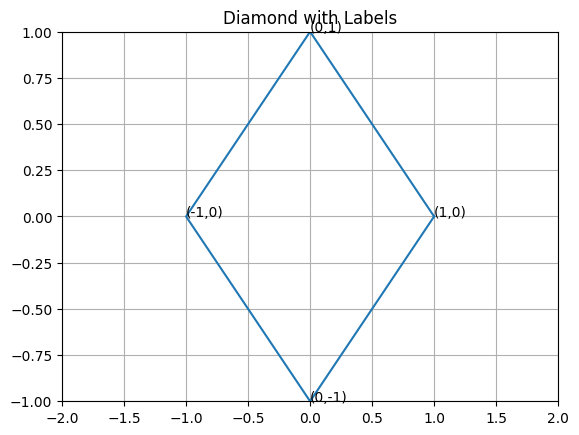

In [ ]:
X = np.array([1, 0, -1, 0, 1])
Y = np.array([0, 1, 0, -1, 0])

plt.figure()
plt.plot(X, Y)
plt.axis([-2, 2, -1, 1])
plt.title("Diamond with Labels")
plt.grid(True)

for i in range(4):
    label = f"({X[i]},{Y[i]})"
    plt.text(X[i], Y[i], label)

plt.show()

### Question 1.9

Modify your grid code to add a coordinate label to each point of the grid.

### Solution

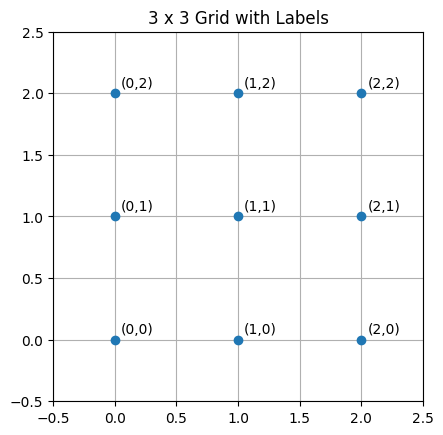

In [ ]:
x_values = np.arange(3)
y_values = np.arange(3)

XX, YY = np.meshgrid(x_values, y_values)
X = XX.ravel()
Y = YY.ravel()

plt.figure()
plt.plot(X, Y, "o", linestyle="None")
plt.axis([-0.5, 2.5, -0.5, 2.5])
plt.gca().set_aspect("equal", adjustable="box")
plt.title("3 x 3 Grid with Labels")
plt.grid(True)

for x, y in zip(X, Y):
    plt.text(x + 0.05, y + 0.05, f"({x},{y})")

plt.show()

### Question 1.10

Use a `for` loop to draw the lines connecting

$$
(0,n) \quad \text{to} \quad (10-n,0)
$$

for $n = 0,1,\ldots,10$.

### Solution

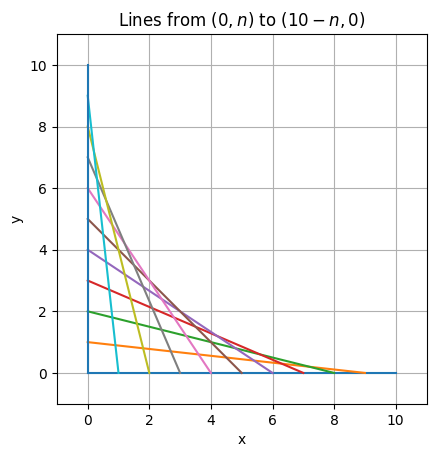

In [ ]:
plt.figure()

for n in range(11):
    plt.plot([0, 10 - n], [n, 0])

plt.title(r"Lines from $(0,n)$ to $(10-n,0)$")
plt.xlabel("x")
plt.ylabel("y")
plt.axis([-1, 11, -1, 11])
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.show()

# 2. Solving Systems of Equations Using Python

A system of $k$ linear equations in $n$ unknowns has the form

$$
a_{11}x_1+\cdots+a_{1n}x_n=b_1,
$$

$$
\vdots
$$

$$
a_{k1}x_1+\cdots+a_{kn}x_n=b_k.
$$

In matrix notation, this is

$$
A\vec{x}=\vec{b}.
$$

Python gives several ways to solve or analyze such a system.

- Use `np.linalg.solve(A,b)` when $A$ is square and invertible.
- Use `np.linalg.lstsq(A,b,rcond=None)` when the system may be overdetermined.
- Use `sympy.Matrix(...).rref()` to see the full row-reduction structure.
- Use `scipy.linalg.null_space(A)` for numerical null spaces.
- Use `sympy.linsolve((A,b))` for exact symbolic solution sets.

## 2.1 Example: Invertible Matrix

Consider

$$
2x_1-2x_2=1,
$$

$$
x_1+4x_2=3.
$$

In [ ]:
A = np.array([[2, -2],
              [1,  4]], dtype=float)

b = np.array([1, 3], dtype=float)

x = np.linalg.solve(A, b)
x

array([1. , 0.5])

We can also form the augmented matrix and compute RREF exactly using `sympy`.

In [ ]:
A_sp = sp.Matrix([[2, -2],
                  [1,  4]])

b_sp = sp.Matrix([1, 3])

Aug = A_sp.row_join(b_sp)
Aug.rref()

(Matrix([
 [1, 0,   1],
 [0, 1, 1/2]]),
 (0, 1))

The RREF says

$$
x_1 = 1,\qquad x_2 = 0.5.
$$

## 2.2 Example: Underdetermined System

Consider

$$
2x_1-2x_2+4x_3=1,
$$

$$
x_1+4x_2-x_3=3.
$$

There are fewer equations than unknowns, so we expect either no solution or infinitely many solutions.

In [ ]:
A_sp = sp.Matrix([[2, -2, 4],
                  [1,  4, -1]])

b_sp = sp.Matrix([1, 3])

Aug = A_sp.row_join(b_sp)
Aug.rref()

(Matrix([
 [1, 0,  7/5,   1],
 [0, 1, -3/5, 1/2]]),
 (0, 1))

The RREF gives

$$
x_1 + 1.4x_3 = 1,
$$

$$
x_2 - 0.6x_3 = 0.5.
$$

Let $x_3=t$. Then

$$
\vec{x}
=
\begin{pmatrix}
1\\
0.5\\
0
\end{pmatrix}
+
t
\begin{pmatrix}
-1.4\\
0.6\\
1
\end{pmatrix}.
$$

In [ ]:
sp.linsolve((A_sp, b_sp))

{(1 - 7*tau0/5, 3*tau0/5 + 1/2, tau0)}

Numerically, `np.linalg.lstsq` returns one solution, not the full solution space.

In [ ]:
A = np.array(A_sp.tolist(), dtype=float)
b = np.array(b_sp.tolist(), dtype=float).ravel()

x_lstsq, residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)

print("One least-squares solution:", x_lstsq)
print("Rank:", rank)
print("Residuals:", residuals)
print("Null space basis:")
print(null_space(A))

One least-squares solution: [0.5361 0.6988 0.3313]
Rank: 2
Residuals: []
Null space basis:
[[-0.7683]
 [ 0.3293]
 [ 0.5488]]


The null space vector is normalized, so it may look different from $(-1.4,0.6,1)$, but it spans the same direction.

## 2.3 Example: Overdetermined System with No Exact Solution

Consider

$$
2x_1-2x_2=1,
$$

$$
x_1+4x_2=3,
$$

$$
4x_1-7x_2=2.
$$

In [ ]:
A_sp = sp.Matrix([[2, -2],
                  [1,  4],
                  [4, -7]])

b_sp = sp.Matrix([1, 3, 2])

Aug = A_sp.row_join(b_sp)
Aug.rref()

(Matrix([
 [1, 0, 0],
 [0, 1, 0],
 [0, 0, 1]]),
 (0, 1, 2))

The row $[0,0,1]$ in the augmented matrix means $0=1$. Therefore, the system has no exact solution.

However, `np.linalg.lstsq` gives the best least-squares approximation.

In [ ]:
A = np.array(A_sp.tolist(), dtype=float)
b = np.array(b_sp.tolist(), dtype=float).ravel()

x_lstsq, residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)

print("Least-squares solution:", x_lstsq)
print("Residuals:", residuals)
print("Rank:", rank)

Least-squares solution: [1.1805 0.4211]
Residuals: [0.3383]
Rank: 2


## 2.4 Example: Overdetermined System with a Unique Exact Solution

Consider

$$
2x_1-2x_2=1,
$$

$$
x_1+4x_2=3,
$$

$$
3x_1-2x_2=2.
$$

In [ ]:
A_sp = sp.Matrix([[2, -2],
                  [1,  4],
                  [3, -2]])

b_sp = sp.Matrix([1, 3, 2])

Aug = A_sp.row_join(b_sp)
Aug.rref()

(Matrix([
 [1, 0,   1],
 [0, 1, 1/2],
 [0, 0,   0]]),
 (0, 1))

In [ ]:
sp.linsolve((A_sp, b_sp))

{(1, 1/2)}

In [ ]:
A = np.array(A_sp.tolist(), dtype=float)
b = np.array(b_sp.tolist(), dtype=float).ravel()

x_lstsq, residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)

print("Solution:", x_lstsq)
print("Residuals:", residuals)
print("Null space:")
print(null_space(A))

Solution: [1.  0.5]
Residuals: [0.]
Null space:
[]


# 2.5 Problems: Linear Systems of Mixed Rank

Use Python to find the full solution space of the following systems.

## Problem 2.5(a)

$$
x_1-x_2+2x_3=1,
$$

$$
2x_1-2x_2+4x_3=1,
$$

$$
-3x_1+3x_2-6x_3=1.
$$

In [ ]:
A_a = sp.Matrix([[1, -1,  2],
                 [2, -2,  4],
                 [-3, 3, -6]])

b_a = sp.Matrix([1, 1, 1])

Aug_a = A_a.row_join(b_a)

print("RREF:")
display(Aug_a.rref()[0])

print("Solution set:")
display(sp.linsolve((A_a, b_a)))

print("rank(A) =", A_a.rank())
print("rank([A|b]) =", Aug_a.rank())

RREF:


Matrix([
[1, -1, 2, 0],
[0,  0, 0, 1],
[0,  0, 0, 0]])

Solution set:


EmptySet

rank(A) = 1
rank([A|b]) = 2


### Solution 2.5(a)

The RREF contains a row equivalent to

$$
0=1.
$$

Therefore, the system is inconsistent and has **no solution**.

## Problem 2.5(b)

$$
x_1-x_2+2x_3=1,
$$

$$
x_1-4x_2+x_3=-1,
$$

$$
3x_1+3x_2-2x_3=2.
$$

In [ ]:
A_b = sp.Matrix([[1, -1,  2],
                 [1, -4,  1],
                 [3,  3, -2]])

b_b = sp.Matrix([1, -1, 2])

Aug_b = A_b.row_join(b_b)

print("RREF:")
display(Aug_b.rref()[0])

print("Solution set:")
display(sp.linsolve((A_b, b_b)))

print("rank(A) =", A_b.rank())
print("rank([A|b]) =", Aug_b.rank())

RREF:


Matrix([
[1, 0, 0, 1/2],
[0, 1, 0, 1/2],
[0, 0, 1, 1/2]])

Solution set:


{(1/2, 1/2, 1/2)}

rank(A) = 3
rank([A|b]) = 3


### Solution 2.5(b)

The system has the unique solution

$$
(x_1,x_2,x_3)=\left(\frac12,\frac12,\frac12\right).
$$

## Problem 2.5(c)

$$
x_1-x_2+2x_3=1,
$$

$$
4x_1-2x_2+x_3=1,
$$

$$
2x_1-3x_3=-1.
$$

In [ ]:
A_c = sp.Matrix([[1, -1,  2],
                 [4, -2,  1],
                 [2,  0, -3]])

b_c = sp.Matrix([1, 1, -1])

Aug_c = A_c.row_join(b_c)

print("RREF:")
display(Aug_c.rref()[0])

print("Solution set:")
display(sp.linsolve((A_c, b_c)))

print("rank(A) =", A_c.rank())
print("rank([A|b]) =", Aug_c.rank())

RREF:


Matrix([
[1, 0, -3/2, -1/2],
[0, 1, -7/2, -3/2],
[0, 0,    0,    0]])

Solution set:


{(3*tau0/2 - 1/2, 7*tau0/2 - 3/2, tau0)}

rank(A) = 2
rank([A|b]) = 2


### Solution 2.5(c)

The system has infinitely many solutions. Let $x_3=t$. Then

$$
x_1=-\frac12+\frac32t,
$$

$$
x_2=-\frac32+\frac72t,
$$

$$
x_3=t.
$$

So

$$
\vec{x}
=
\begin{pmatrix}
-\frac12\\
-\frac32\\
0
\end{pmatrix}
+
t
\begin{pmatrix}
\frac32\\
\frac72\\
1
\end{pmatrix}.
$$

# 3. Linear Problems with Unknown Parameters

Many real linear systems depend on parameters. These parameters may be measured from the outside world or determined by computation.

One important application is static force analysis for truss structures. The idea is:

1. Each joint is static, so the net force at each joint is zero.
2. Each force is decomposed into $x$- and $y$-components.
3. The force-balance equations form a linear system.
4. Solving the linear system gives support forces and internal truss forces.

We assume all internal truss forces are initially in **tension**. If a computed truss force is negative, then that truss is actually in **compression**.

## 3.1 Example: Three-Bar Truss

Consider a triangular truss with vertices

$$
A=(-1,0),\qquad B=(0,\sqrt{3}),\qquad C=(1,0).
$$

The internal angles are $\pi/3$, so

$$
\cos(\pi/3)=\frac12,\qquad \sin(\pi/3)=\frac{\sqrt3}{2}.
$$

The unknowns are ordered as

$$
(R_1,R_2,T_1,T_2,T_3).
$$

Using the force equations from the MATLAB lab, the matrix system is

$$
A\vec{x}=\vec{b}.
$$

In [ ]:
c = np.cos(np.pi / 3)
s = np.sin(np.pi / 3)

A = np.array([
    [ 0,  0,  c,  0,  1],
    [-1,  0,  s,  0,  0],
    [ 0,  0,  0, -c, -1],
    [ 0, -1,  0,  s,  0],
    [ 0,  0, -s, -s,  0],
    [ 0,  0, -c,  c,  0]
], dtype=float)

A

array([[ 0.   ,  0.   ,  0.5  ,  0.   ,  1.   ],
       [-1.   ,  0.   ,  0.866,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , -0.5  , -1.   ],
       [ 0.   , -1.   ,  0.   ,  0.866,  0.   ],
       [ 0.   ,  0.   , -0.866, -0.866,  0.   ],
       [ 0.   ,  0.   , -0.5  ,  0.5  ,  0.   ]])

### Example 3.1

Assume a downward force of $1000$ N is applied at vertex $B$. Solve for the support forces and truss forces.

In [ ]:
B = np.array([0, 0, 0, 0, 1000, 0], dtype=float)

solution, residuals, rank, singular_values = np.linalg.lstsq(A, B, rcond=None)

labels = ["R1", "R2", "T1", "T2", "T3"]

for label, value in zip(labels, solution):
    print(f"{label} = {value:.4f}")

R1 = -500.0000
R2 = -500.0000
T1 = -577.3503
T2 = -577.3503
T3 = 288.6751


### Interpretation

The output should be approximately

$$
R_1=-500,\quad R_2=-500,
$$

$$
T_1=-577.3503,\quad T_2=-577.3503,\quad T_3=288.6751.
$$

Negative values mean the actual direction is opposite our assumed direction.

Therefore:

- $T_1$ and $T_2$ are in compression.
- $T_3$ is in tension.
- The support reactions $R_1$ and $R_2$ act upward if the diagram originally assumed downward arrows.

## 3.2 Visualizing the Three-Bar Truss

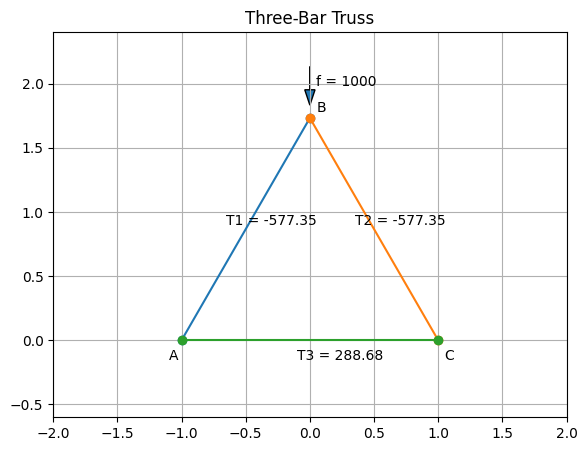

In [ ]:
A_point = np.array([-1, 0])
B_point = np.array([0, np.sqrt(3)])
C_point = np.array([1, 0])

plt.figure(figsize=(7, 5))

# Draw bars
plt.plot([A_point[0], B_point[0]], [A_point[1], B_point[1]], "o-")
plt.plot([B_point[0], C_point[0]], [B_point[1], C_point[1]], "o-")
plt.plot([A_point[0], C_point[0]], [A_point[1], C_point[1]], "o-")

# Labels
plt.text(A_point[0]-0.1, A_point[1]-0.15, "A")
plt.text(B_point[0]+0.05, B_point[1]+0.05, "B")
plt.text(C_point[0]+0.05, C_point[1]-0.15, "C")

# Force arrow at B
plt.arrow(B_point[0], B_point[1]+0.4, 0, -0.3, head_width=0.08, length_includes_head=True)
plt.text(B_point[0]+0.05, B_point[1]+0.25, "f = 1000")

# Annotate truss forces
plt.text(-0.65, 0.9, f"T1 = {solution[2]:.2f}")
plt.text(0.35, 0.9, f"T2 = {solution[3]:.2f}")
plt.text(-0.1, -0.15, f"T3 = {solution[4]:.2f}")

plt.axis([-2, 2, -0.6, 2.4])
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Three-Bar Truss")
plt.grid(True)
plt.show()

## 3.3 Symbolic Parameter Solution

Now let the downward force be a symbolic variable $f$. We solve the system exactly.

In [ ]:
f = sp.symbols("f")

c_sp = sp.Rational(1, 2)
s_sp = sp.sqrt(3) / 2

A_sp = sp.Matrix([
    [ 0,  0,  c_sp,  0,     1],
    [-1,  0,  s_sp,  0,     0],
    [ 0,  0,  0,    -c_sp, -1],
    [ 0, -1,  0,     s_sp,  0],
    [ 0,  0, -s_sp, -s_sp,  0],
    [ 0,  0, -c_sp,  c_sp,  0]
])

B_sp = sp.Matrix([0, 0, 0, 0, f, 0])

symbolic_solution = A_sp.gauss_jordan_solve(B_sp)[0]
symbolic_solution

Matrix([
[        -f/2],
[        -f/2],
[-sqrt(3)*f/3],
[-sqrt(3)*f/3],
[ sqrt(3)*f/6]])

Thus

$$
R_1=R_2=-\frac{f}{2},
$$

$$
T_1=T_2=-\frac{\sqrt3}{3}f,
$$

$$
T_3=\frac{\sqrt3}{6}f.
$$

If $T_3=1000$, then

$$
\frac{\sqrt3}{6}f=1000,
$$

so

$$
f=\frac{6000}{\sqrt3}=2000\sqrt3.
$$

In [ ]:
f_required = sp.solve(sp.Eq(symbolic_solution[4], 1000), f)[0]
f_required, float(f_required)

(2000*sqrt(3), 3464.1016151377544)

# 3.4 Final Truss Problem

Now consider the larger truss from the original lab. The internal angles are $\pi/3$. We use the following coordinates:

$$
A=(-1,0), \quad B=(0,\sqrt3), \quad C=(1,0), \quad D=(2,\sqrt3), \quad E=(3,0).
$$

The trusses are:

- $T_1$: $A$ to $B$
- $T_2$: $B$ to $C$
- $T_3$: $C$ to $D$
- $T_4$: $D$ to $E$
- $T_5$: $A$ to $C$
- $T_6$: $C$ to $E$
- $T_7$: $B$ to $D$

The support/external reaction unknowns are $R_1,R_2,R_3$. We order the unknown vector as

$$
\vec{x}
=
(R_1,R_2,R_3,T_1,T_2,T_3,T_4,T_5,T_6,T_7)^T.
$$

The external applied forces are:

- $f_1$: downward force at $B$
- $f_2$: leftward force at $D$

The force balance equations at the five joints give 10 scalar equations.

## 3.4.1 Constructing the Matrix System

Let

$$
c=\cos(\pi/3)=\frac12,\qquad s=\sin(\pi/3)=\frac{\sqrt3}{2}.
$$

The equations are:

At $A$:

$$
-R_2+cT_1+T_5=0,
$$

$$
-R_1+sT_1=0.
$$

At $B$:

$$
-cT_1+cT_2+T_7=0,
$$

$$
-sT_1-sT_2=f_1.
$$

At $C$:

$$
-cT_2+cT_3-T_5+T_6=0,
$$

$$
sT_2+sT_3=0.
$$

At $D$:

$$
-cT_3+cT_4-T_7=f_2,
$$

$$
-sT_3-sT_4=0.
$$

At $E$:

$$
-cT_4-T_6=0,
$$

$$
-R_3+sT_4=0.
$$

In [ ]:
c = np.cos(np.pi / 3)
s = np.sin(np.pi / 3)

# Unknown order:
# R1, R2, R3, T1, T2, T3, T4, T5, T6, T7
A_big = np.array([
    [ 0, -1,  0,  c,  0,  0,  0,  1,  0,  0],  # A x
    [-1,  0,  0,  s,  0,  0,  0,  0,  0,  0],  # A y
    [ 0,  0,  0, -c,  c,  0,  0,  0,  0,  1],  # B x
    [ 0,  0,  0, -s, -s,  0,  0,  0,  0,  0],  # B y
    [ 0,  0,  0,  0, -c,  c,  0, -1,  1,  0],  # C x
    [ 0,  0,  0,  0,  s,  s,  0,  0,  0,  0],  # C y
    [ 0,  0,  0,  0,  0, -c,  c,  0,  0, -1],  # D x
    [ 0,  0,  0,  0,  0, -s, -s,  0,  0,  0],  # D y
    [ 0,  0,  0,  0,  0,  0, -c,  0, -1,  0],  # E x
    [ 0,  0, -1,  0,  0,  0,  s,  0,  0,  0],  # E y
], dtype=float)

A_big

array([[ 0.   , -1.   ,  0.   ,  0.5  ,  0.   ,  0.   ,  0.   ,  1.   ,
         0.   ,  0.   ],
       [-1.   ,  0.   ,  0.   ,  0.866,  0.   ,  0.   ,  0.   ,  0.   ,
         0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , -0.5  ,  0.5  ,  0.   ,  0.   ,  0.   ,
         0.   ,  1.   ],
       [ 0.   ,  0.   ,  0.   , -0.866, -0.866,  0.   ,  0.   ,  0.   ,
         0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   , -0.5  ,  0.5  ,  0.   , -1.   ,
         1.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.866,  0.866,  0.   ,  0.   ,
         0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   , -0.5  ,  0.5  ,  0.   ,
         0.   , -1.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   , -0.866, -0.866,  0.   ,
         0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   , -0.5  ,  0.   ,
        -1.   ,  0.   ],
       [ 0.   ,  0.   , -1.   ,  0.   ,  0.   ,  0.   ,  0.866,  0.   ,
         0.   ,  0.   ]])

## 3.4.2 Problem 1

Construct and solve the system when

$$
f_1=100,\qquad f_2=1000.
$$

In [ ]:
f1_value = 100
f2_value = 1000

b_big = np.array([0, 0, 0, f1_value, 0, 0, f2_value, 0, 0, 0], dtype=float)

solution_big = np.linalg.solve(A_big, b_big)

labels_big = ["R1", "R2", "R3", "T1", "T2", "T3", "T4", "T5", "T6", "T7"]

for label, value in zip(labels_big, solution_big):
    print(f"{label} = {value:10.4f}")

R1 =  -508.0127
R2 = -1000.0000
R3 =   408.0127
T1 =  -586.6025
T2 =   471.1325
T3 =  -471.1325
T4 =   471.1325
T5 =  -706.6987
T6 =  -235.5662
T7 =  -528.8675


### Interpretation

A positive truss force agrees with the assumed tension direction.

A negative truss force means the member is actually in compression.

In [ ]:
for label, value in zip(labels_big[3:], solution_big[3:]):
    if value > 0:
        status = "tension"
    elif value < 0:
        status = "compression"
    else:
        status = "zero force"
    print(f"{label}: {value:10.4f}  ->  {status}")

T1:  -586.6025  ->  compression
T2:   471.1325  ->  tension
T3:  -471.1325  ->  compression
T4:   471.1325  ->  tension
T5:  -706.6987  ->  compression
T6:  -235.5662  ->  compression
T7:  -528.8675  ->  compression


## 3.4.3 Symbolic Solution for the Large Truss

Now solve in terms of $f_1$ and $f_2$.

In [ ]:
f1, f2 = sp.symbols("f1 f2")

c_sp = sp.Rational(1, 2)
s_sp = sp.sqrt(3) / 2

A_big_sp = sp.Matrix([
    [ 0, -1,  0,  c_sp,  0,     0,     0,     1,  0,  0],
    [-1,  0,  0,  s_sp,  0,     0,     0,     0,  0,  0],
    [ 0,  0,  0, -c_sp,  c_sp,  0,     0,     0,  0,  1],
    [ 0,  0,  0, -s_sp, -s_sp,  0,     0,     0,  0,  0],
    [ 0,  0,  0,  0,    -c_sp,  c_sp,  0,    -1,  1,  0],
    [ 0,  0,  0,  0,     s_sp,  s_sp,  0,     0,  0,  0],
    [ 0,  0,  0,  0,     0,    -c_sp,  c_sp,  0,  0, -1],
    [ 0,  0,  0,  0,     0,    -s_sp, -s_sp,  0,  0,  0],
    [ 0,  0,  0,  0,     0,     0,    -c_sp, 0, -1,  0],
    [ 0,  0, -1,  0,     0,     0,     s_sp, 0,  0,  0],
])

b_big_sp = sp.Matrix([0, 0, 0, f1, 0, 0, f2, 0, 0, 0])

symbolic_big = A_big_sp.LUsolve(b_big_sp)

for label, expr in zip(labels_big, symbolic_big):
    print(f"{label} = {sp.simplify(expr)}")

R1 = -3*f1/4 - sqrt(3)*f2/4
R2 = -f2
R3 = -f1/4 + sqrt(3)*f2/4
T1 = -sqrt(3)*f1/2 - f2/2
T2 = -sqrt(3)*f1/6 + f2/2
T3 = sqrt(3)*f1/6 - f2/2
T4 = -sqrt(3)*f1/6 + f2/2
T5 = sqrt(3)*f1/4 - 3*f2/4
T6 = sqrt(3)*f1/12 - f2/4
T7 = -sqrt(3)*f1/6 - f2/2


The most important component for the next questions is

$$
T_3=\frac{\sqrt3}{6}f_1-\frac12 f_2.
$$

In [ ]:
T3_expr = sp.simplify(symbolic_big[5])
T3_expr

sqrt(3)*f1/6 - f2/2

## 3.4.4 Problem 2

Assume $f_1=100$. What must $f_2$ be for the force $T_3$ to have magnitude $1000$?

Since magnitude is specified, we solve

$$
|T_3|=1000.
$$

There are two algebraic possibilities:

$$
T_3=1000
\qquad \text{or} \qquad
T_3=-1000.
$$

In [ ]:
solutions_T3_positive = sp.solve(sp.Eq(T3_expr.subs(f1, 100), 1000), f2)
solutions_T3_negative = sp.solve(sp.Eq(T3_expr.subs(f1, 100), -1000), f2)

print("If T3 = 1000:")
display(solutions_T3_positive[0])
print(float(solutions_T3_positive[0]))

print("\nIf T3 = -1000:")
display(solutions_T3_negative[0])
print(float(solutions_T3_negative[0]))

If T3 = 1000:


-2000 + 100*sqrt(3)/3

-1942.2649730810374

If T3 = -1000:


100*sqrt(3)/3 + 2000

2057.7350269189624


### Interpretation

If $f_2$ is defined as a leftward force, then a positive $f_2$ means the force points left. The physically natural positive-leftward answer is usually obtained from $T_3=-1000$:

$$
f_2 = 2000+\frac{100\sqrt3}{3}
\approx 2034.641.
$$

This gives $|T_3|=1000$ with $T_3$ negative, meaning the member is in compression under the assumed tension sign convention.

If the problem specifically asks for $T_3=1000$, not magnitude, then

$$
f_2 = -2000+\frac{100\sqrt3}{3}
\approx -1942.265.
$$

The negative sign means the actual $f_2$ direction is opposite the assumed leftward arrow.

## 3.4.5 Problem 3

Assume the maximum force that can be applied along $T_3$ is $1000$. Give an equation relating $f_1$ and $f_2$ when $T_3=1000$.

Since

$$
T_3=\frac{\sqrt3}{6}f_1-\frac12 f_2,
$$

the equation $T_3=1000$ is

$$
\frac{\sqrt3}{6}f_1-\frac12 f_2=1000.
$$

Equivalently,

$$
f_2=\frac{\sqrt3}{3}f_1-2000.
$$

If the condition is instead $|T_3|=1000$, then

$$
\left|\frac{\sqrt3}{6}f_1-\frac12 f_2\right|=1000.
$$

In [ ]:
equation_T3_1000 = sp.Eq(T3_expr, 1000)
equation_abs_T3_1000 = sp.Eq(sp.Abs(T3_expr), 1000)

display(equation_T3_1000)
display(sp.solve(equation_T3_1000, f2)[0])

Eq(sqrt(3)*f1/6 - f2/2, 1000)

sqrt(3)*f1/3 - 2000

# 3.5 Visualizing the Large Truss

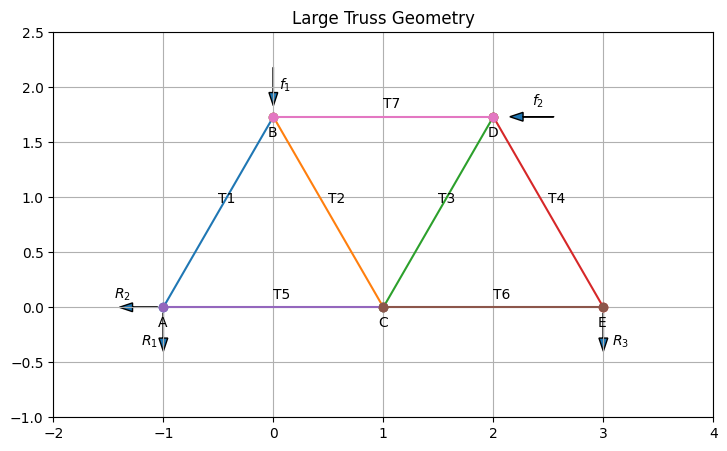

In [ ]:
points = {
    "A": np.array([-1, 0]),
    "B": np.array([0, np.sqrt(3)]),
    "C": np.array([1, 0]),
    "D": np.array([2, np.sqrt(3)]),
    "E": np.array([3, 0]),
}

bars = [
    ("A", "B", "T1"),
    ("B", "C", "T2"),
    ("C", "D", "T3"),
    ("D", "E", "T4"),
    ("A", "C", "T5"),
    ("C", "E", "T6"),
    ("B", "D", "T7"),
]

plt.figure(figsize=(9, 5))

for p, q, label in bars:
    P = points[p]
    Q = points[q]
    plt.plot([P[0], Q[0]], [P[1], Q[1]], "o-")
    midpoint = (P + Q) / 2
    plt.text(midpoint[0], midpoint[1] + 0.08, label)

for name, P in points.items():
    plt.text(P[0] - 0.05, P[1] - 0.18, name)

# Force arrows
B = points["B"]
D = points["D"]
Apt = points["A"]
E = points["E"]

plt.arrow(B[0], B[1] + 0.45, 0, -0.35, head_width=0.08, length_includes_head=True)
plt.text(B[0] + 0.05, B[1] + 0.25, r"$f_1$")

plt.arrow(D[0] + 0.55, D[1], -0.4, 0, head_width=0.08, length_includes_head=True)
plt.text(D[0] + 0.35, D[1] + 0.1, r"$f_2$")

plt.arrow(Apt[0], Apt[1] - 0.05, 0, -0.35, head_width=0.08, length_includes_head=True)
plt.text(Apt[0] - 0.2, Apt[1] - 0.35, r"$R_1$")

plt.arrow(Apt[0] - 0.05, Apt[1], -0.35, 0, head_width=0.08, length_includes_head=True)
plt.text(Apt[0] - 0.45, Apt[1] + 0.08, r"$R_2$")

plt.arrow(E[0], E[1] - 0.05, 0, -0.35, head_width=0.08, length_includes_head=True)
plt.text(E[0] + 0.08, E[1] - 0.35, r"$R_3$")

plt.title("Large Truss Geometry")
plt.axis([-2, 4, -1, 2.5])
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.show()

# 4. Additional Practice Problems

These problems reinforce the Python version of the MATLAB lab.

## Practice Problem 1: Shape Checking

Create:

$$
u=\begin{pmatrix}1\\2\\3\end{pmatrix},
\qquad
v=\begin{pmatrix}4\\5\\6\end{pmatrix}.
$$

Compute:

1. $u^Tv$
2. $uv^T$
3. $u+v$
4. $u-v$

Explain the shape of each result.

In [ ]:
u = np.array([[1], [2], [3]])
v = np.array([[4], [5], [6]])

print("u.T @ v =")
print(u.T @ v)
print("shape:", (u.T @ v).shape)

print("\nu @ v.T =")
print(u @ v.T)
print("shape:", (u @ v.T).shape)

print("\nu + v =")
print(u + v)
print("shape:", (u + v).shape)

print("\nu - v =")
print(u - v)
print("shape:", (u - v).shape)

u.T @ v =
[[32]]
shape: (1, 1)

u @ v.T =
[[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]
shape: (3, 3)

u + v =
[[5]
 [7]
 [9]]
shape: (3, 1)

u - v =
[[-3]
 [-3]
 [-3]]
shape: (3, 1)


## Practice Problem 2: Plot a Parametric Curve

Plot the curve

$$
x(t)=\cos(t),\qquad y(t)=\sin(t),
$$

for $0\le t\le 2\pi$.

What shape do you get?

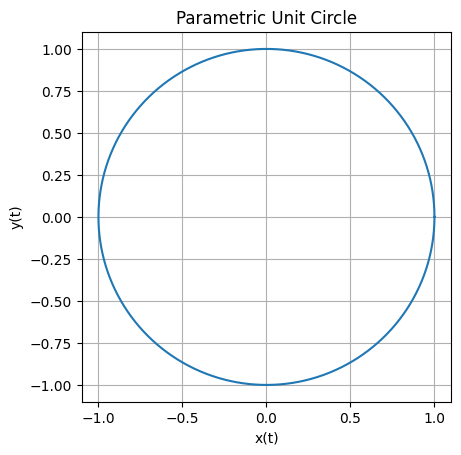

In [ ]:
t = np.linspace(0, 2*np.pi, 500)
x = np.cos(t)
y = np.sin(t)

plt.figure()
plt.plot(x, y)
plt.title("Parametric Unit Circle")
plt.xlabel("x(t)")
plt.ylabel("y(t)")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.show()

## Practice Problem 3: Linear Transformation of a Shape

Use the matrix

$$
A=
\begin{pmatrix}
2 & 1\\
0 & 1
\end{pmatrix}
$$

to transform the diamond from Section 1.5.3. Plot the original and transformed diamond on the same axes.

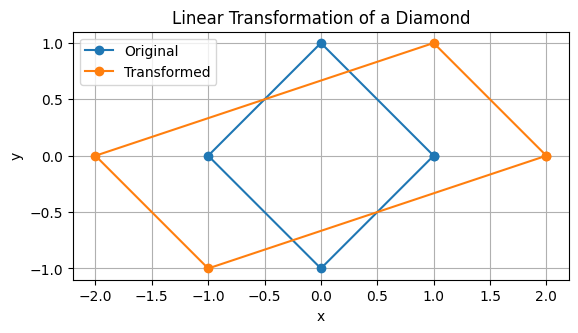

In [ ]:
diamond = np.array([
    [1, 0, -1, 0, 1],
    [0, 1, 0, -1, 0]
])

A_transform = np.array([[2, 1],
                        [0, 1]])

transformed = A_transform @ diamond

plt.figure()
plt.plot(diamond[0, :], diamond[1, :], "o-", label="Original")
plt.plot(transformed[0, :], transformed[1, :], "o-", label="Transformed")
plt.title("Linear Transformation of a Diamond")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.grid(True)
plt.show()

## Practice Problem 4: Least-Squares Fit

Generate noisy data from

$$
y=2x+1
$$

and use least squares to estimate the slope and intercept.

Estimated slope: 2.0324565699311146
Estimated intercept: 0.7178393290331838


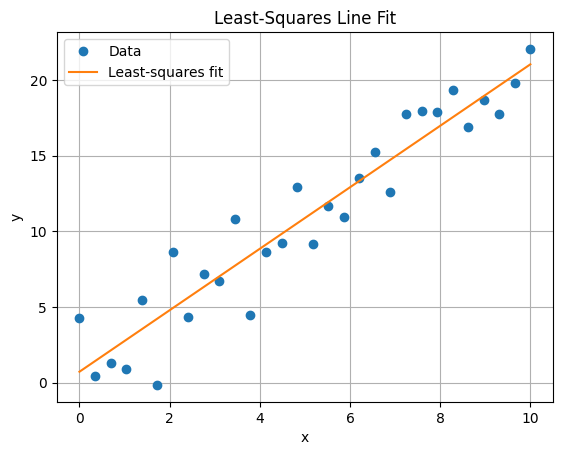

In [ ]:
np.random.seed(1)

x_data = np.linspace(0, 10, 30)
y_data = 2*x_data + 1 + np.random.normal(0, 2, size=x_data.shape)

# Design matrix for y = mx + b
A_design = np.column_stack([x_data, np.ones_like(x_data)])

m_est, b_est = np.linalg.lstsq(A_design, y_data, rcond=None)[0]

print("Estimated slope:", m_est)
print("Estimated intercept:", b_est)

plt.figure()
plt.plot(x_data, y_data, "o", label="Data")
plt.plot(x_data, m_est*x_data + b_est, label="Least-squares fit")
plt.title("Least-Squares Line Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 5. Summary

In this Python version of the lab, we learned how to:

1. Use Python as a calculator.
2. Work with variables and expressions.
3. Construct vectors and matrices using `numpy`.
4. Understand shapes, transposes, matrix multiplication, and broadcasting.
5. Construct special matrices and sequences.
6. Plot functions and geometric objects using `matplotlib`.
7. Use loops to automate computation and plotting.
8. Solve linear systems using both numerical and symbolic methods.
9. Interpret RREF, rank, null spaces, least-squares solutions, and full solution spaces.
10. Build and solve truss-force linear systems.

The most important habit is to check shapes and interpret the mathematics behind the computation. Python can compute quickly, but mathematical reasoning tells us what the computation means.